*plotting code cells!*

first section: functions, masks, and pre-work


In [1]:
using Oceananigans
using CairoMakie
using Printf

# will vary this with differen tlocations 
location_name = "Amazon"
source_longitude = -49.5
source_latitude = 0.16

# data raw 
data_directory = raw"C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\new jld2 files\no spinups\80 day salinity dye"
analysis_directory = raw"C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\new analysis notebooks"

analysis_output_directory = joinpath(analysis_directory, "analysis outputs")
mkpath(analysis_output_directory)

# file paths 
dye_file = joinpath(data_directory, "amazon_rivers_on_80d_dye.jld2")
salinity_file = joinpath(data_directory, "amazon_rivers_on_80d_salinity_3d.jld2")
surface_file = joinpath(data_directory, "amazon_rivers_on_80d_surface_fields.jld2")
free_surface_file = joinpath(data_directory, "amazon_rivers_on_80d_free_surface.jld2")

# load only the requested day rather than the whole file using OnDisk
dye_3d = FieldTimeSeries(dye_file, "dye"; backend=OnDisk())
salinity_3d = FieldTimeSeries(salinity_file, "S"; backend=OnDisk())

# oceananigans time is in seconds; convert to days 
days_saved = Float64.(dye_3d.times) ./ 86400
number_of_times = length(days_saved)

81

In [ ]:
# calculate cell areas/volumes to be used in other plots 

# get coordinates at tracer-cell CENTERS; these line up with saved dye and salinity.
longitude, latitude, depth = nodes(dye_3d.grid, Center(), Center(), Center())

# get cell FACE coordinates; the vertical faces give the real layer thicknesses.
longitude_faces, latitude_faces, depth_faces = nodes(dye_3d.grid, Face(), Face(), Face())

# mean Earth radius in meters.
earth_radius = 6.371e6

# amazon area assumption 
# get grid spacing by subtracting the first two face coords in horizontal directoin
longitude_spacing_degrees = abs(longitude_faces[2] - longitude_faces[1])
latitude_spacing_degrees = abs(latitude_faces[2] - latitude_faces[1])

# at equator, distance = Earth radius * angular distance in radians.
cell_width_meters = earth_radius * deg2rad(longitude_spacing_degrees)
cell_height_meters = earth_radius * deg2rad(latitude_spacing_degrees)

# use one representative horizontal area for every Amazon grid cell.
representative_cell_area = cell_width_meters * cell_height_meters
cell_area = fill(representative_cell_area, length(longitude), length(latitude))

# volume calculations
layer_thickness = abs.(diff(depth_faces))

# reshape makes thickness 1-by-1-by-Nz, just multiply depth by 2d area to get volume
cell_volume = cell_area .* reshape(layer_thickness, 1, 1, length(layer_thickness))

# load day-0 salinity. interior removes halo cells; Array and Float64 make a normal numeric array.
initial_salinity = Float64.(Array(interior(salinity_3d[1])))


# masks: iterate over these in loops to determine what quantities to be computed

# active water must be finite and positive to be put in this array 
wet_cell = isfinite.(initial_salinity) .& (initial_salinity .> 0)

# the last vertical index is the surface layer, so this gives a 2d mask of wet cells at the surface
surface_wet = wet_cell[:, :, end]

# make a 3d mask of wet cells shallower than 100 m. --> for uppr 100 m fraction plots 
upper_100m_mask = wet_cell .& reshape(depth .>= -100, 1, 1, length(depth))

# distance function on the earth for plotting dye travel distance laterally 
# looked this up online its called the haversine formula, returns dist in km. 
function haversine_km(longitude_1, latitude_1, longitude_2, latitude_2)
    delta_lambda = deg2rad(longitude_2 - longitude_1) # east-west difference
    delta_phi = deg2rad(latitude_2 - latitude_1)       # north-south difference
    phi_1 = deg2rad(latitude_1)
    phi_2 = deg2rad(latitude_2)
    a = sin(delta_phi / 2)^2 + cos(phi_1) * cos(phi_2) * sin(delta_lambda / 2)^2
    return 2 * earth_radius / 1000 * asin(sqrt(clamp(a, 0, 1)))
end

# calculate release-point distance at every horizontal cell center. 2d array of distances from source point to every grid cell center
# again used to calculate dye distance travelled laterally 
distance_from_source = [
    haversine_km(source_longitude, source_latitude, lon, lat)
    for lon in longitude, lat in latitude
]

# active ocean cells that are both wet and within 100 or 250 km of source point
within_100km = wet_cell .& reshape(distance_from_source .<= 100, length(longitude), length(latitude), 1)
within_250km = wet_cell .& reshape(distance_from_source .<= 250, length(longitude), length(latitude), 1)

# prevent Jupyter from printing a huge Boolean array.
nothing

Representative Amazon horizontal cell area: 30.911 km^2
Horizontal cell size used here: 5.560 km by 5.560 km


In [ ]:
# detecting plume spreading thresholds RELATIVE to initial surface maximum (.01%, 1%, 10% of init surface max)
footprint_thresholds = (1e-3, 1e-2, 1e-1)

# preallocate one value per day for each inventory or transport metric.
total_inventory = zeros(number_of_times)
upper_100m_inventory = zeros(number_of_times)
layer_inventory = zeros(length(depth), number_of_times)
fraction_within_100km = zeros(number_of_times)
fraction_within_250km = zeros(number_of_times)
surface_footprint_km2 = zeros(number_of_times, length(footprint_thresholds))
centroid_longitude = zeros(number_of_times)
centroid_latitude = zeros(number_of_times)
centroid_distance_km = zeros(number_of_times)
east_west_spread_km = zeros(number_of_times)
north_south_spread_km = zeros(number_of_times)

# preallocate extrema for model quality-control checks.
salinity_minimum = zeros(number_of_times)
salinity_maximum = zeros(number_of_times)
dye_minimum = zeros(number_of_times)
dye_maximum = zeros(number_of_times)

# find the active-ocean surface maximum at day 0; footprint thresholds use this baseline.
initial_dye = Float64.(Array(interior(dye_3d[1])))
initial_surface_maximum = maximum(initial_dye[:, :, end][surface_wet])

# read in 3d fields one day at a time 
for n in eachindex(days_saved)
    # load the day
    # remove halo cells (interior)
    dye_field = Float64.(Array(interior(dye_3d[n])))
    salinity_field = Float64.(Array(interior(salinity_3d[n])))

    # treat non-finite and non-ocean dye values as zero before summing.
    dye_field[.!isfinite.(dye_field)] .= 0
    dye_field[.!wet_cell] .= 0

    # get tracer amount per cell and fill in the array 
    # concentration times cell volume gives a volume-weighted tracer amount per cell.
    dye_mass = dye_field .* cell_volume
    total_inventory[n] = sum(dye_mass)
    upper_100m_inventory[n] = sum(dye_mass[upper_100m_mask])

    # sum each depth layer separately for the vertical profile and table.
    for k in eachindex(depth)
        layer_inventory[k, n] = sum(dye_mass[:, :, k])
    end

    # fill in fraction of dye currently inside each fixed radius around the release point
    fraction_within_100km[n] = sum(dye_mass[within_100km]) / total_inventory[n]
    fraction_within_250km[n] = sum(dye_mass[within_250km]) / total_inventory[n]

    # area-weight surface dye for the footprint, centroid, and spread metrics.
    surface_dye = dye_field[:, :, end]
    surface_weight = surface_dye .* cell_area
    surface_mass = sum(surface_weight)

    # sum the area exceeding each relative dye threshold.
    for (m, threshold) in enumerate(footprint_thresholds)
        footprint_mask = surface_wet .& (surface_dye .>= threshold * initial_surface_maximum)
        surface_footprint_km2[n, m] = sum(cell_area[footprint_mask]) / 1e6
    end

    # dye-weighted surface centroid.
    centroid_longitude[n] = sum(surface_weight .* reshape(longitude, length(longitude), 1)) / surface_mass
    centroid_latitude[n] = sum(surface_weight .* reshape(latitude, 1, length(latitude))) / surface_mass
    centroid_distance_km[n] = haversine_km(source_longitude, source_latitude, centroid_longitude[n], centroid_latitude[n])

    # convert longitude degrees to km and calculate dye-weighted standard deviations.
    longitude_scale = 111.32 * cosd(centroid_latitude[n])
    east_west_spread_km[n] = sqrt(sum(surface_weight .* ((reshape(longitude, length(longitude), 1) .- centroid_longitude[n]) .* longitude_scale).^2) / surface_mass)
    north_south_spread_km[n] = sqrt(sum(surface_weight .* ((reshape(latitude, 1, length(latitude)) .- centroid_latitude[n]) .* 111.32).^2) / surface_mass)

    # record active-ocean extrema, not land or solid-bottom zeros.
    salinity_minimum[n] = minimum(salinity_field[wet_cell])
    salinity_maximum[n] = maximum(salinity_field[wet_cell])
    dye_minimum[n] = minimum(dye_field[wet_cell])
    dye_maximum[n] = maximum(dye_field[wet_cell])
end

# normalize by day-0 inventory so the curves are fractions of the initial release.
initial_inventory = total_inventory[1]
domain_fraction = total_inventory ./ initial_inventory
upper_100m_fraction = upper_100m_inventory ./ initial_inventory
below_100m_fraction = (total_inventory .- upper_100m_inventory) ./ initial_inventory


Finished the standardized calculations.


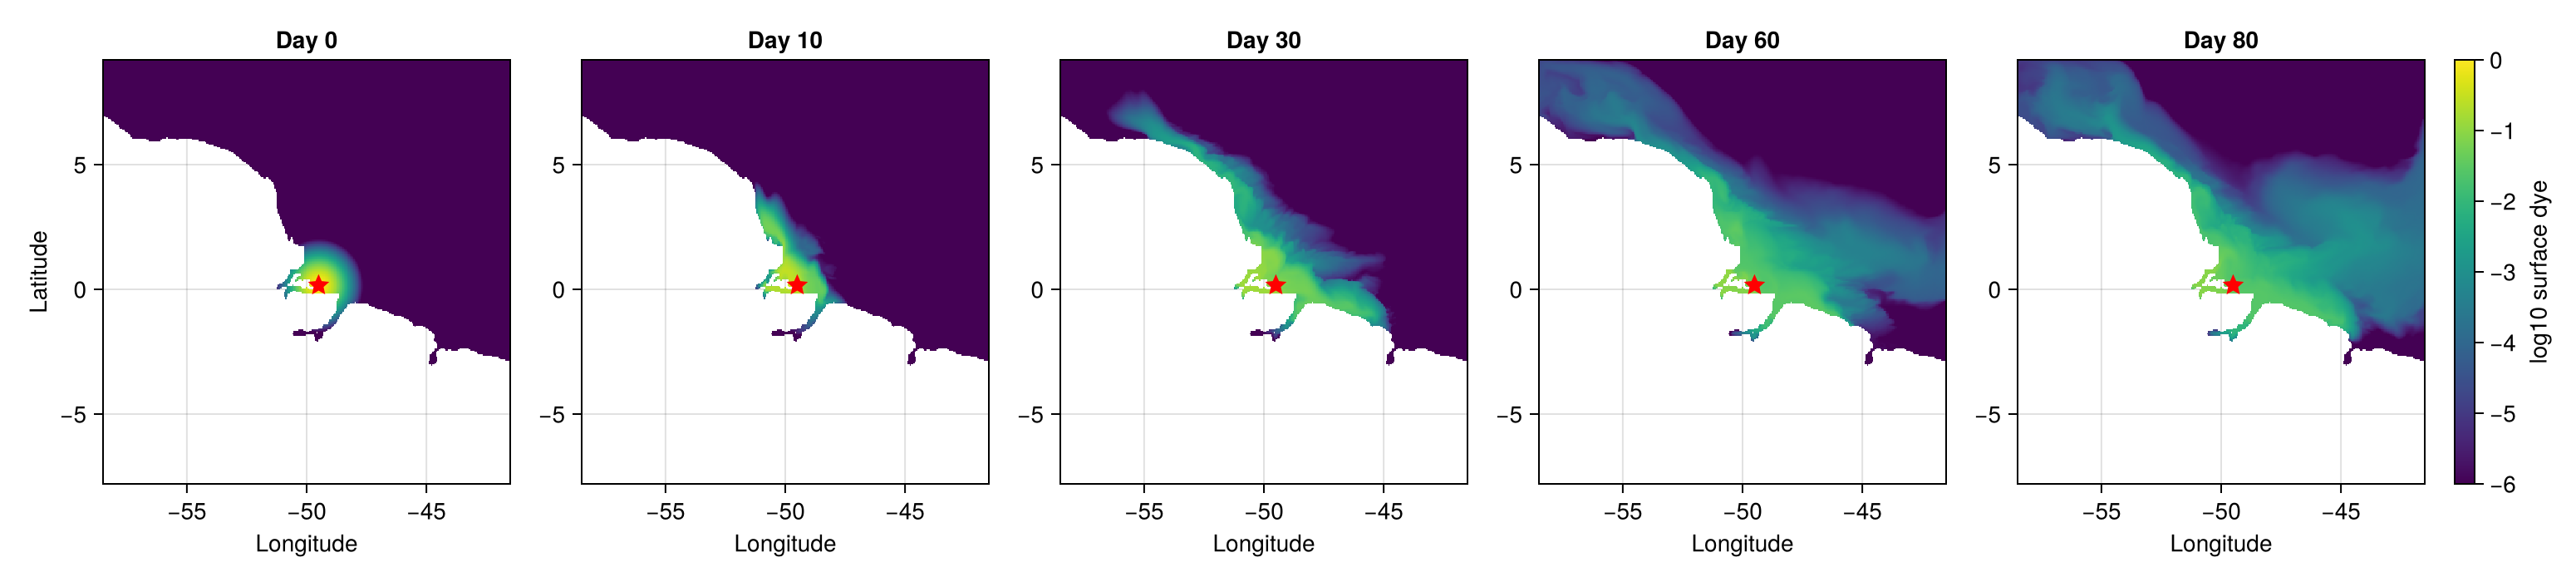

In [ ]:
# select five clear times and find the nearest saved index for each.
map_days = [0.0, 10.0, 30.0, 60.0, 80.0]
map_indices = [argmin(abs.(days_saved .- day)) for day in map_days]

# create five map panels plus a shared colorbar.
surface_map_figure = Figure(size=(1550, 350))

for (panel, time_index) in enumerate(map_indices)
    # load the chosen day and keep the surface dye layer.
    surface_dye = Float64.(Array(interior(dye_3d[time_index])))[:, :, end]

    # NaN plots as blank, so land does not look like zero-dye ocean.
    surface_dye[.!surface_wet] .= NaN

    # only repeat the latitude label on the first panel.
    axis = Axis(surface_map_figure[1, panel], xlabel="Longitude", ylabel=panel == 1 ? "Latitude" : "", title="Day $(Int(round(days_saved[time_index])))")

    # log10 shows the strong core and dilute plume together; max avoids log10(0).
    heatmap!(axis, longitude, latitude, log10.(max.(surface_dye, 1e-12)); colorrange=(-6, 0), colormap=:viridis)

    # red star = fixed dye-release location.
    scatter!(axis, [source_longitude], [source_latitude], color=:red, marker=:star5, markersize=15)
end

# add the shared colorbar, save a PNG, and display the figure.
Colorbar(surface_map_figure[1, 6], limits=(-6, 0), colormap=:viridis, label="log10 surface dye")
save(joinpath(analysis_output_directory, "amazon_output1_surface_evolution.png"), surface_map_figure)
surface_map_figure

In [6]:
# Return the first day a time series reaches or drops below a chosen value.
function first_day_below(values, threshold)
    index = findfirst(value -> value <= threshold, values)
    return isnothing(index) ? missing : days_saved[index]
end

# t50 = first day only 50% of the dye remains within that radius.
t50_100km = first_day_below(fraction_within_100km, 0.5)
t50_250km = first_day_below(fraction_within_250km, 0.5)

# Print meeting-ready values instead of estimating them visually from curves.
@printf("Day 80 within 100 km: %.3f\n", fraction_within_100km[end])
@printf("Day 80 within 250 km: %.3f\n", fraction_within_250km[end])
println("100-km t50: ", ismissing(t50_100km) ? "> $(last(days_saved)) days" : "$(t50_100km) days")
println("250-km t50: ", ismissing(t50_250km) ? "> $(last(days_saved)) days" : "$(t50_250km) days")

Day 80 within 100 km: 0.186
Day 80 within 250 km: 0.631
100-km t50: 22.0 days
250-km t50: > 80.0 days


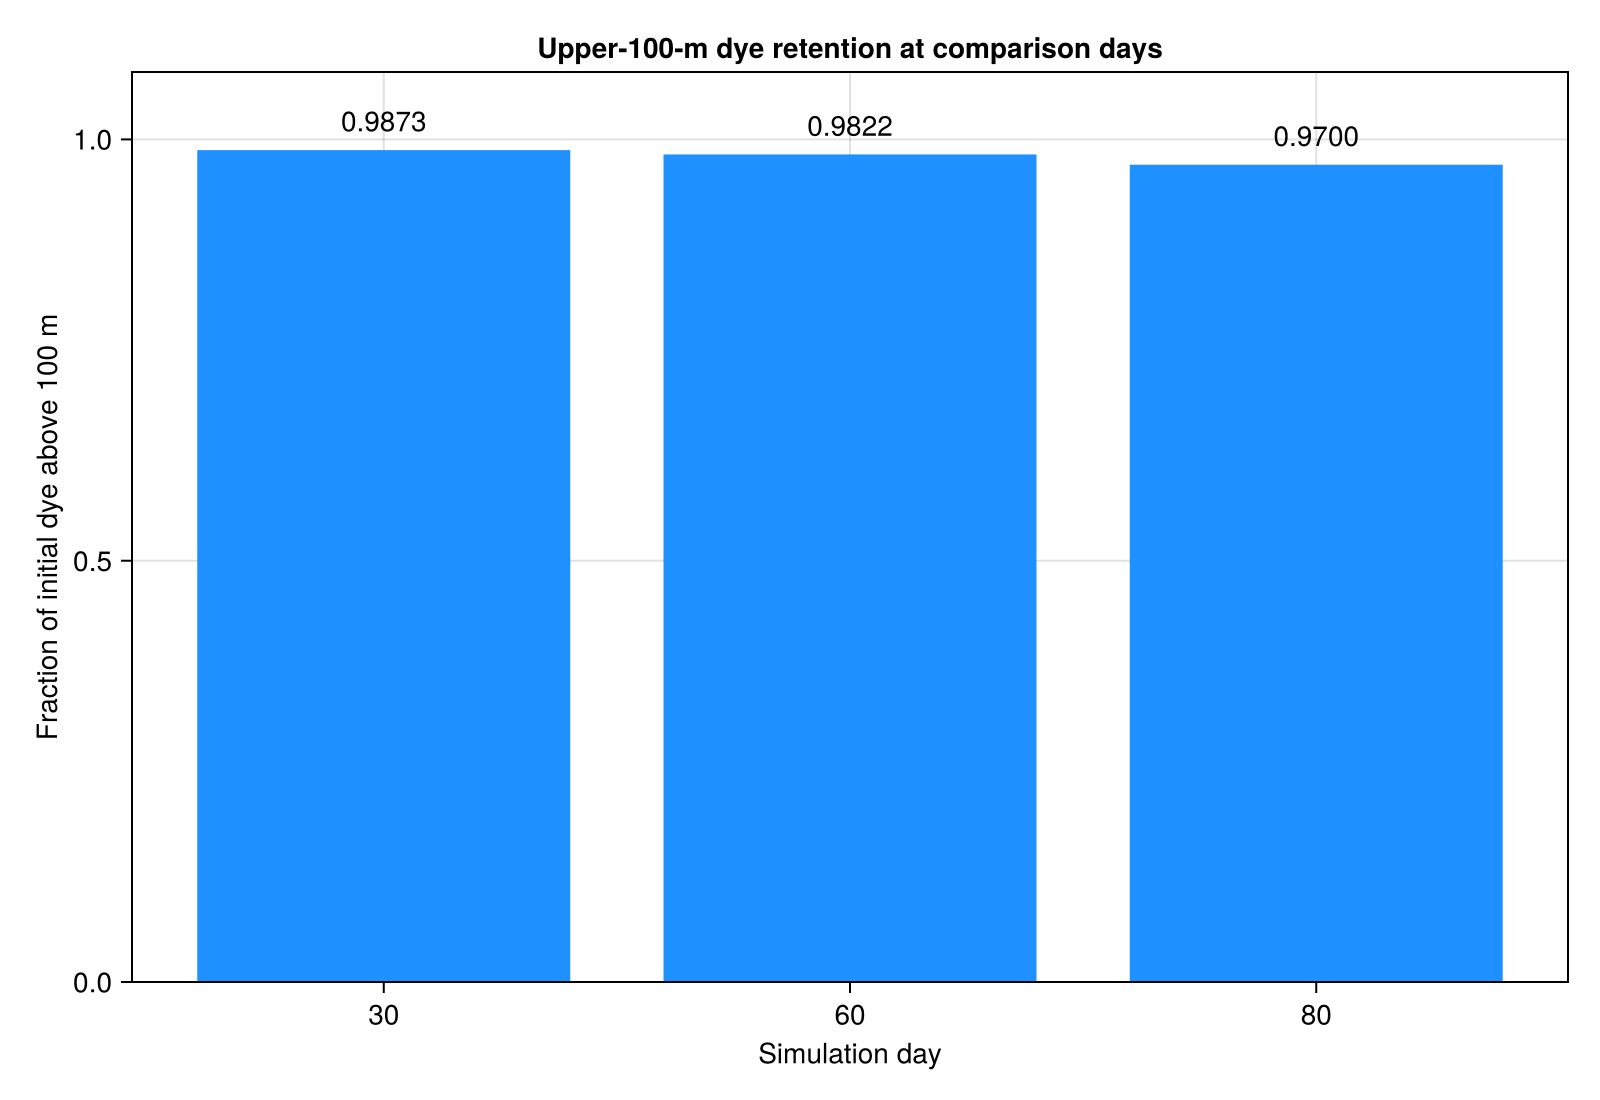

In [ ]:
# pick the three standardized comparison days requested for the regional analysis.
upper_100m_snapshot_days = [30.0, 60.0, 80.0]

# find the saved model-output index nearest each requested day.
upper_100m_snapshot_indices = [argmin(abs.(days_saved .- day)) for day in upper_100m_snapshot_days]

# upper_100m_fraction was calculated as upper-100-m inventory divided by DAY-0 total inventory.
upper_100m_snapshot_fraction = upper_100m_fraction[upper_100m_snapshot_indices]

# Use simple positions 1, 2, and 3 for the three bars.
bar_positions = 1:length(upper_100m_snapshot_days)

# create the bar plot.
upper_100m_snapshot_figure = Figure(size=(800, 550))
upper_100m_snapshot_axis = Axis(
    upper_100m_snapshot_figure[1, 1],
    xlabel="Simulation day",
    ylabel="Fraction of initial dye above 100 m",
    title="Upper-100-m dye retention at comparison days",
    xticks=(bar_positions, string.(Int.(upper_100m_snapshot_days)))
)

# plot one bar per day. All bars use the same definition and day-0 denominator.
barplot!(upper_100m_snapshot_axis, bar_positions, upper_100m_snapshot_fraction, color=:dodgerblue)

# write the exact fraction above each bar
for (position, fraction) in zip(bar_positions, upper_100m_snapshot_fraction)
    text!(upper_100m_snapshot_axis, position, fraction + 0.015; text=@sprintf("%.4f", fraction), align=(:center, :bottom))
end

# fractions should fall between zero and one; the extra 0.08 leaves room for the value labels.
ylims!(upper_100m_snapshot_axis, 0, 1.08)

save(joinpath(analysis_output_directory, "amazon_upper100_fraction_days30_60_80.png"), upper_100m_snapshot_figure)
upper_100m_snapshot_figure

In [ ]:
# fixed depth boundaries make the vertical result easy to report as a table
report_depths = [-30.0, -50.0, -100.0, -200.0, -500.0]

# print the header
@printf("%-8s", "Day")
for boundary in report_depths
    @printf(" %12s", "above $(Int(abs(boundary)))m")
end
println()

# print one row per selected day
for (column, day) in enumerate(vertical_days)
    @printf("%-8.0f", day)
    for boundary in report_depths
        # find centers at or above the boundary and choose the deepest included center
        included_levels = findall(depth .>= boundary)
        deepest_included_level = first(included_levels)
        @printf(" %12.5f", cumulative_fraction_above[deepest_included_level, column])
    end
    println()
end

Day         above 30m    above 50m   above 100m   above 200m   above 500m
10            1.00000      1.00000      1.00000      1.00000      1.00000
30            0.99596      0.99961      0.99999      1.00000      1.00000
60            0.95753      0.98694      0.99647      0.99970      1.00000
80            0.92160      0.96494      0.98519      0.99725      0.99997


BEYOND THIS: same plotting code as before

In [ ]:
# define the transect from the source toward the day-80 surface-dye centroid.
# this follows the modeled plume instead of choosing an arbitrary compass direction.
eastward_km = (centroid_longitude[end] - source_longitude) * 111.32 * cosd(source_latitude)
northward_km = (centroid_latitude[end] - source_latitude) * 111.32

# normalize the two-component direction vector to length one.
direction_norm = hypot(eastward_km, northward_km)
eastward_unit = eastward_km / direction_norm
northward_unit = northward_km / direction_norm

# propose points every 5 km, starting at the mouth and extending up to 600 km.
transect_distance_km = collect(0.0:5.0:600.0)

# convert distances along that direction back into longitude and latitude.
transect_longitude = source_longitude .+ transect_distance_km .* eastward_unit ./ (111.32 * cosd(source_latitude))
transect_latitude = source_latitude .+ transect_distance_km .* northward_unit ./ 111.32

# keep only points inside the model's longitude and latitude limits.
inside_domain = (transect_longitude .>= minimum(longitude)) .& (transect_longitude .<= maximum(longitude)) .&
                (transect_latitude .>= minimum(latitude)) .& (transect_latitude .<= maximum(latitude))
transect_distance_km = transect_distance_km[inside_domain]
transect_longitude = transect_longitude[inside_domain]
transect_latitude = transect_latitude[inside_domain]

# Find the nearest model-grid index for each geographic transect point.
transect_i = [argmin(abs.(longitude .- value)) for value in transect_longitude]
transect_j = [argmin(abs.(latitude .- value)) for value in transect_latitude]

nothing

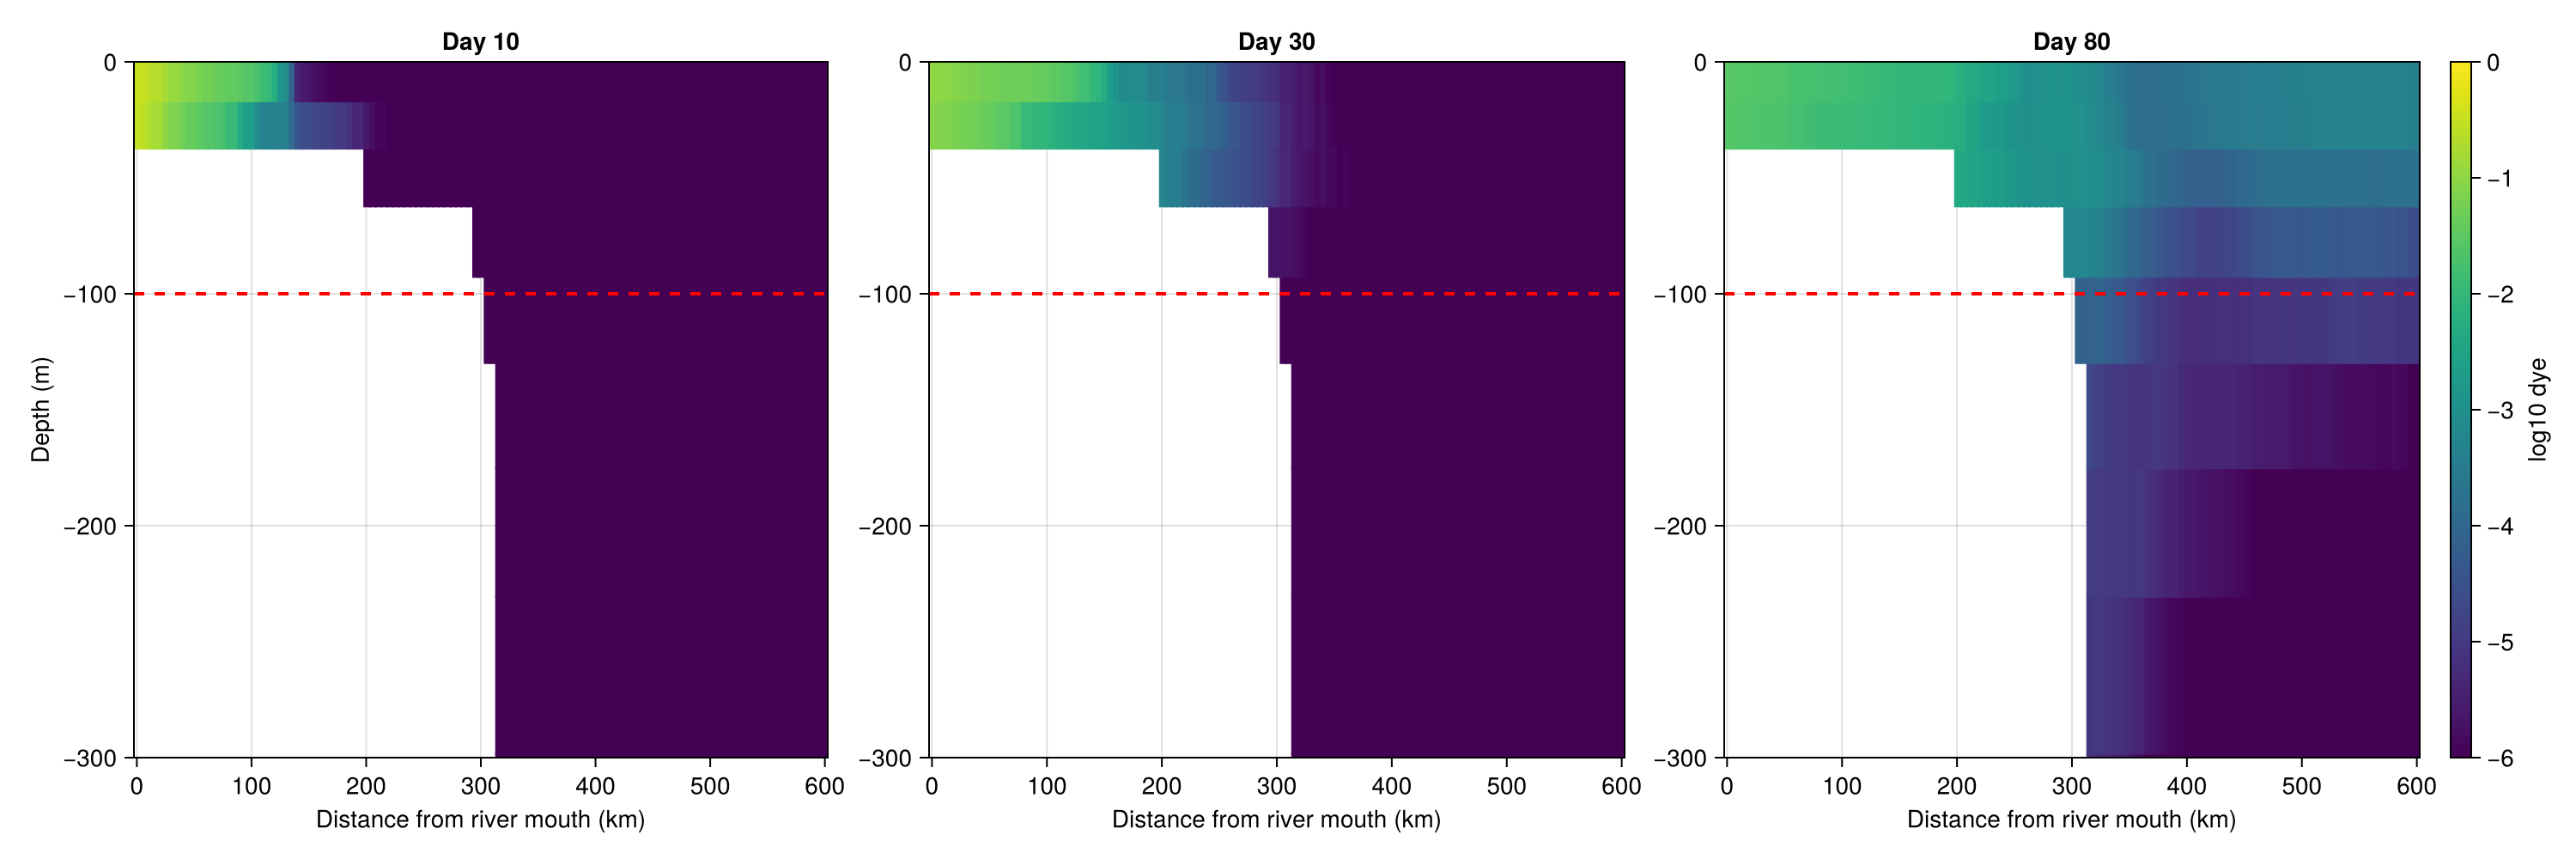

In [ ]:
# FIGURE: transect along the plume (spreading nicely)
# show early, middle, and final sections along the plume-following transect.
transect_days = [10.0, 30.0, 80.0]
transect_indices = [argmin(abs.(days_saved .- day)) for day in transect_days]
transect_figure = Figure(size=(1500, 500))

for (panel, time_index) in enumerate(transect_indices)
    # Load the full dye field for this day.
    dye_field = Float64.(Array(interior(dye_3d[time_index])))

    # Start with NaN so land and solid bottom remain blank.
    dye_section = fill(NaN, length(transect_distance_km), length(depth))

    # nearest-neighbor sample every distance and depth along the transect.
    for point in eachindex(transect_distance_km), k in eachindex(depth)
        i = transect_i[point]
        j = transect_j[point]
        if wet_cell[i, j, k]
            dye_section[point, k] = dye_field[i, j, k]
        end
    end

    # only the first panel repeats the depth label.
    axis = Axis(transect_figure[1, panel], xlabel="Distance from river mouth (km)", ylabel=panel == 1 ? "Depth (m)" : "", title="Day $(Int(round(days_saved[time_index])))")

    # dye-only log plot
    heatmap!(axis, transect_distance_km, depth, log10.(max.(dye_section, 1e-12)); colorrange=(-6, 0), colormap=:viridis)

    # The one red dashed line marks 100 m.
    hlines!(axis, [-100], color=:red, linestyle=:dash, linewidth=2)
    ylims!(axis, -300, 0)
end

# add one colorbar, save, and display.
Colorbar(transect_figure[1, 4], limits=(-6, 0), colormap=:viridis, label="log10 dye")
save(joinpath(analysis_output_directory, "amazon_output3_plume_transect.png"), transect_figure)
transect_figure

In [ ]:
# Open the saved surface variables on disk for the familiar six-panel overview and MP4.
# These cells do not need the expensive 3D inventory loop above.
surface_u = FieldTimeSeries(surface_file, "u"; backend=OnDisk())
surface_v = FieldTimeSeries(surface_file, "v"; backend=OnDisk())
surface_temperature = FieldTimeSeries(surface_file, "T"; backend=OnDisk())
surface_salinity = FieldTimeSeries(surface_file, "S"; backend=OnDisk())
surface_tke = FieldTimeSeries(surface_file, "e"; backend=OnDisk())
surface_dye = FieldTimeSeries(surface_file, "dye"; backend=OnDisk())

# The free-surface key is Greek eta; constructing the character avoids keyboard-encoding trouble.
surface_height = FieldTimeSeries(free_surface_file, string(Char(0x03b7)); backend=OnDisk())

# Get horizontal coordinates directly from the surface tracer grid.
# This prevents the animation from depending on longitude and latitude defined in the earlier 3D-analysis cell.
animation_longitude, animation_latitude, animation_depth = nodes(surface_temperature.grid, Center(), Center(), Center())

# Use the shortest series so no variable is asked for a frame it does not have.
number_of_animation_frames = minimum(length.((surface_u.times, surface_v.times, surface_temperature.times, surface_salinity.times, surface_tke.times, surface_dye.times, surface_height.times)))
animation_days = Float64.(surface_temperature.times[1:number_of_animation_frames]) ./ 86400

# u and v live on staggered faces; average adjacent faces to tracer-cell centers, then calculate speed.
function center_surface_velocity(u_field, v_field)
    u = Float64.(Array(interior(u_field)))
    v = Float64.(Array(interior(v_field)))
    u_center = 0.5 .* (u[1:end-1, :, :] .+ u[2:end, :, :])
    v_center = 0.5 .* (v[:, 1:end-1, :] .+ v[:, 2:end, :])
    return dropdims(sqrt.(u_center.^2 .+ v_center.^2), dims=3)
end

# Surface files may be Nx-by-Ny or Nx-by-Ny-by-1.
# Remove the length-one vertical dimension only when it exists.
function two_dimensional_surface(field)
    array = Float64.(Array(interior(field)))
    return ndims(array) == 3 ? dropdims(array, dims=3) : array
end

initial_surface_salinity = two_dimensional_surface(surface_salinity[1])
animation_surface_wet = isfinite.(initial_surface_salinity) .& (initial_surface_salinity .> 0)

function general_surface_fields(n)
    speed = center_surface_velocity(surface_u[n], surface_v[n])
    temperature = two_dimensional_surface(surface_temperature[n])
    salinity = two_dimensional_surface(surface_salinity[n])
    tke = two_dimensional_surface(surface_tke[n])
    dye = two_dimensional_surface(surface_dye[n])
    eta = two_dimensional_surface(surface_height[n])

    # Blank land so it is not confused with real zero-valued ocean.
    for field in (speed, temperature, salinity, tke, dye, eta)
        field[.!animation_surface_wet] .= NaN
    end

    # Return a NamedTuple; dye is log-transformed because every frame uses that scale.
    return (speed=speed, eta=eta, temperature=temperature, tke=tke, dye=log10.(max.(dye, 1e-12)), salinity=salinity)
end

general_surface_fields (generic function with 1 method)

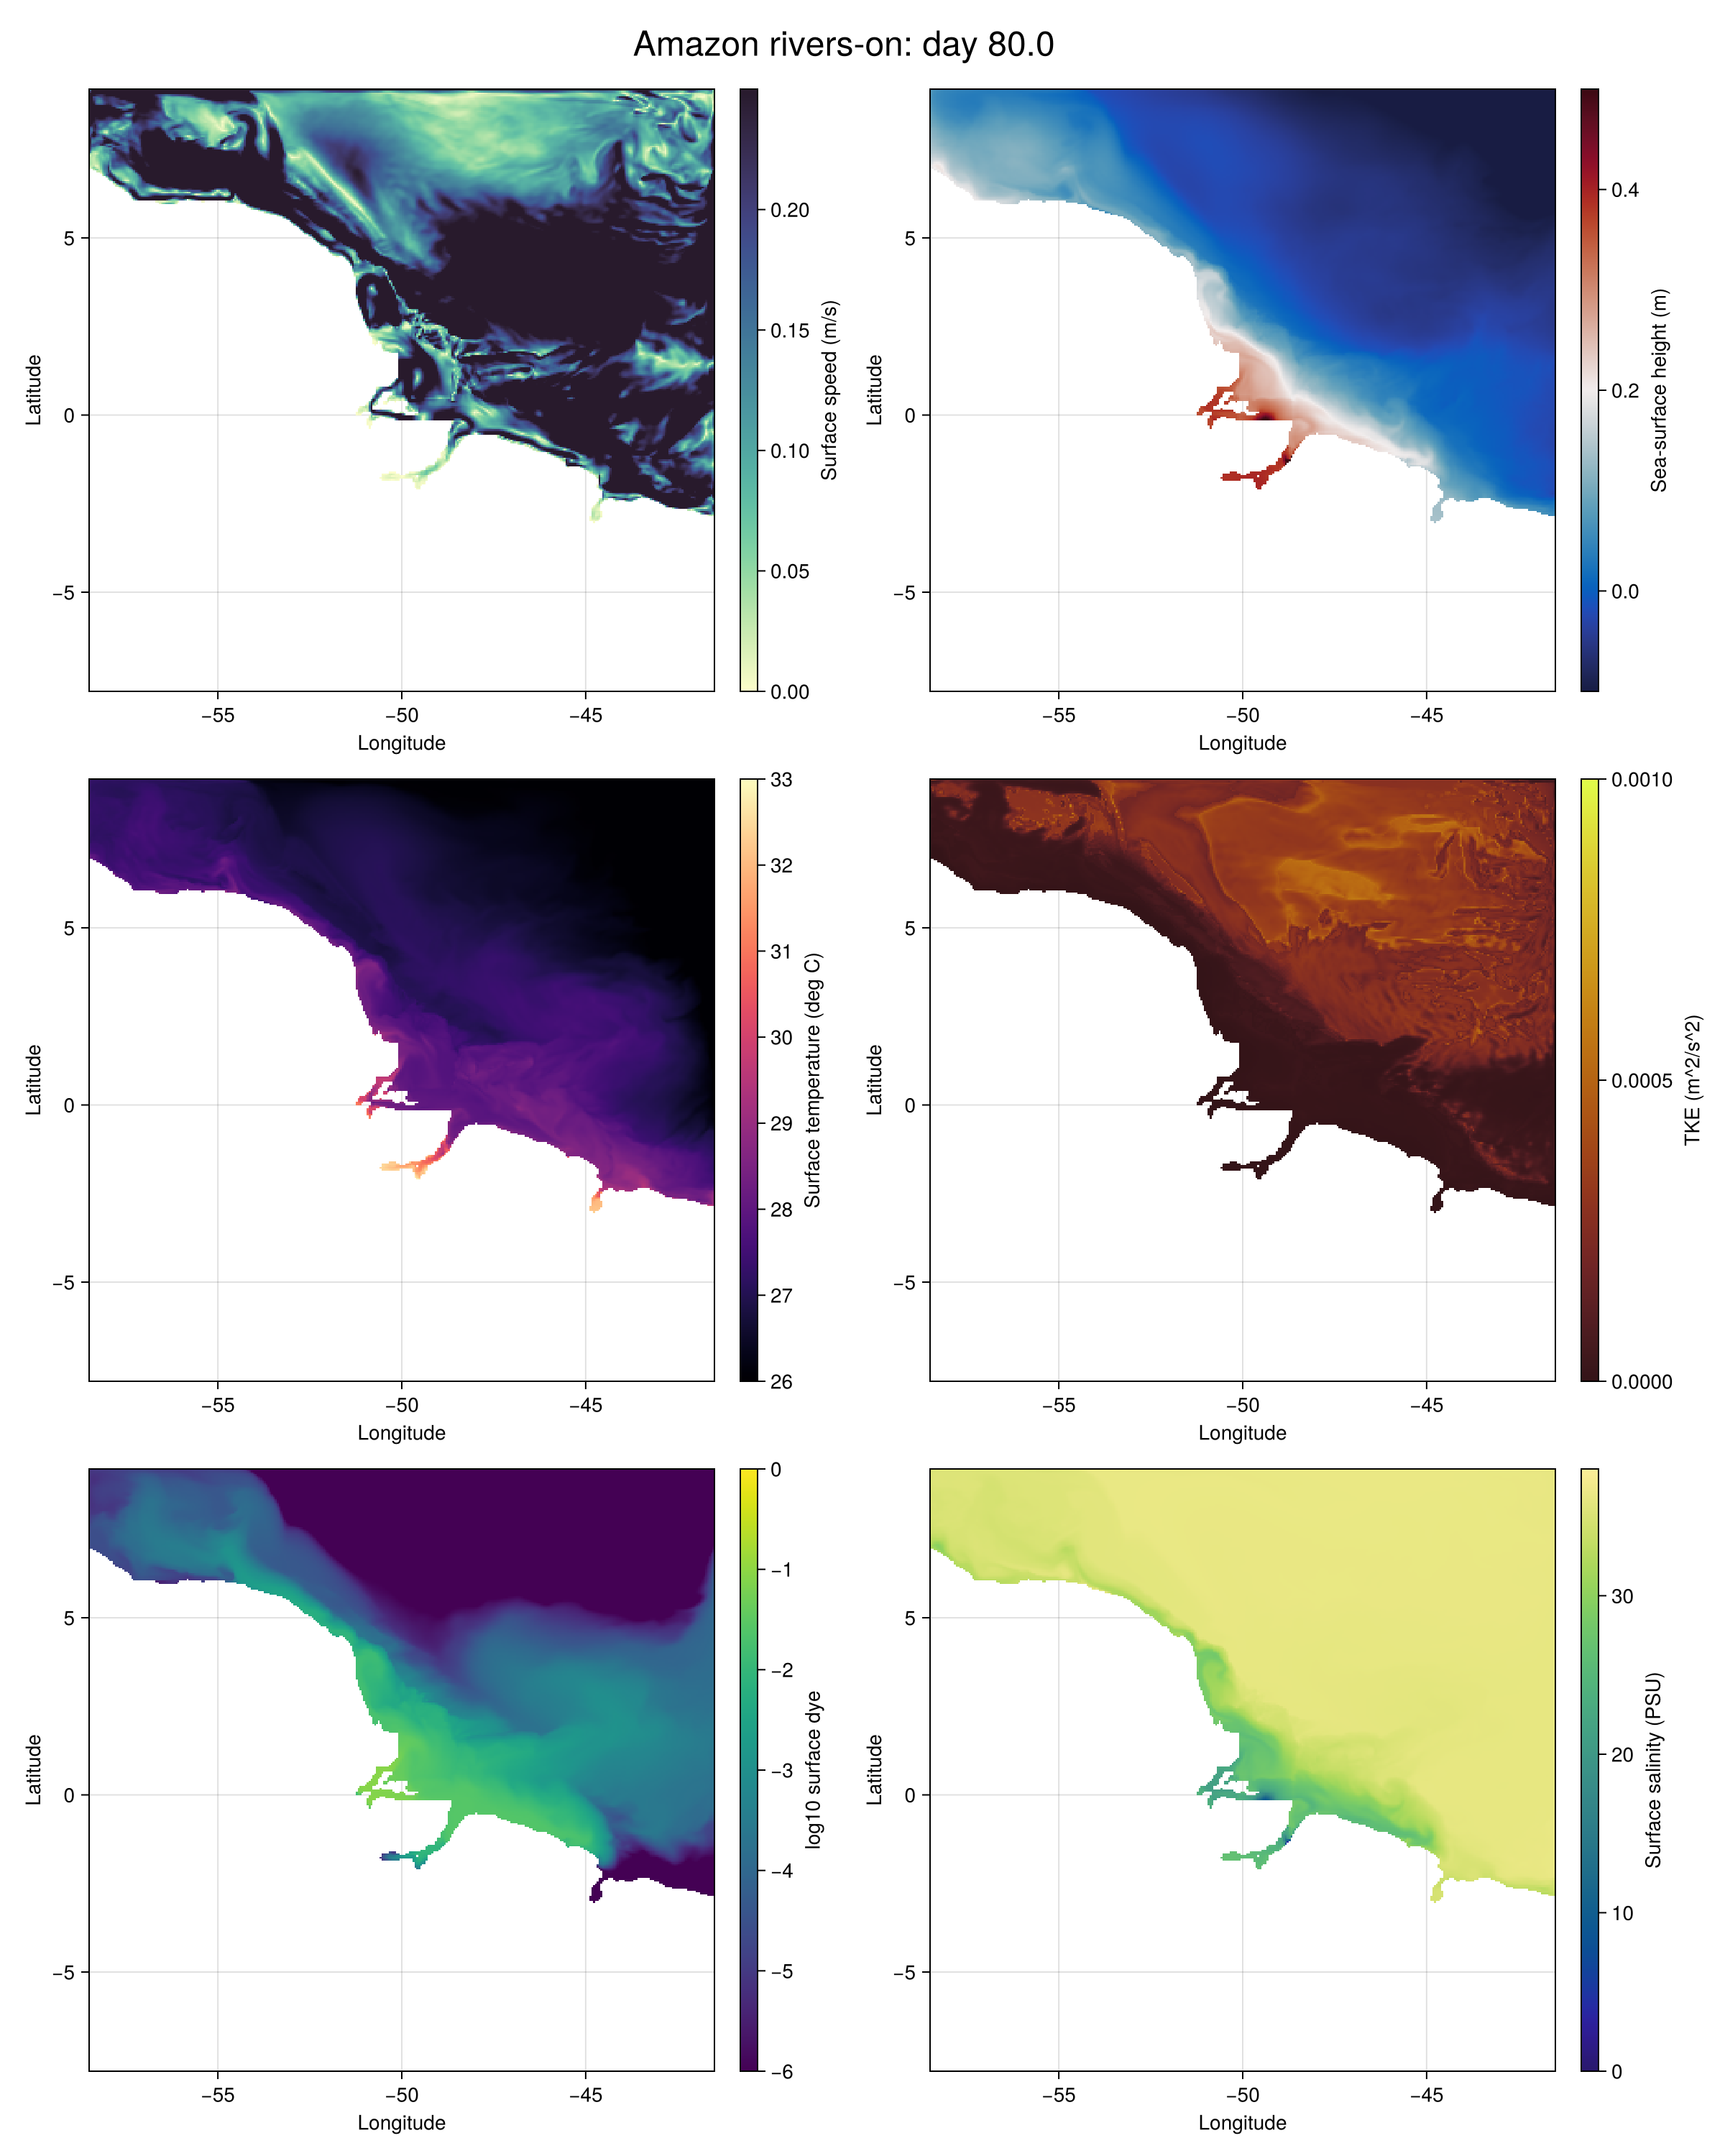

In [15]:
# Observable is a Makie value that can change. Start at the final frame for the static day-80 snapshot.
frame = Observable(number_of_animation_frames)

# Changing frame reloads all six prepared fields.
fields_observable = lift(n -> general_surface_fields(n), frame)
speed_observable = lift(fields -> fields.speed, fields_observable)
eta_observable = lift(fields -> fields.eta, fields_observable)
temperature_observable = lift(fields -> fields.temperature, fields_observable)
tke_observable = lift(fields -> fields.tke, fields_observable)
dye_observable = lift(fields -> fields.dye, fields_observable)
salinity_observable = lift(fields -> fields.salinity, fields_observable)

# Make the title update with the model day.
title_observable = lift(n -> "$location_name rivers-on: day $(round(animation_days[n], digits=1))", frame)

# Build a 3-by-2 panel figure; the extra columns hold colorbars.
general_figure = Figure(size=(1200, 1500))
general_axes = [Axis(general_figure[row, column]) for row in 1:3, column in (1, 3)]

# Fixed color ranges make colors comparable between animation frames.
# Use the animation-specific coordinates created in the preceding cell.
plots = (
    heatmap!(general_axes[1, 1], animation_longitude, animation_latitude, speed_observable, colorrange=(0, 0.25), colormap=:deep),
    heatmap!(general_axes[1, 2], animation_longitude, animation_latitude, eta_observable, colorrange=(-0.1, 0.5), colormap=:balance),
    heatmap!(general_axes[2, 1], animation_longitude, animation_latitude, temperature_observable, colorrange=(26, 33), colormap=:magma),
    heatmap!(general_axes[2, 2], animation_longitude, animation_latitude, tke_observable, colorrange=(0, 1e-3), colormap=:solar),
    heatmap!(general_axes[3, 1], animation_longitude, animation_latitude, dye_observable, colorrange=(-6, 0), colormap=:viridis),
    heatmap!(general_axes[3, 2], animation_longitude, animation_latitude, salinity_observable, colorrange=(0, 38), colormap=:haline)
)

# Labels follow the same order as plots.
labels = ("Surface speed (m/s)", "Sea-surface height (m)", "Surface temperature (deg C)", "TKE (m^2/s^2)", "log10 surface dye", "Surface salinity (PSU)")

# Add two colorbars per row. 2row means 2 * row in Julia.
for row in 1:3
    Colorbar(general_figure[row, 2], plots[2row - 1], label=labels[2row - 1])
    Colorbar(general_figure[row, 4], plots[2row], label=labels[2row])
end

# Label every map and add the changing title.
for axis in general_axes
    axis.xlabel = "Longitude"
    axis.ylabel = "Latitude"
end
Label(general_figure[0, :], title_observable, fontsize=24)

# frame began at the final index, so this is the day-80 overview snapshot.
save(joinpath(analysis_output_directory, "amazon_general_tracer_snapshot_day80.png"), general_figure)
general_figure

In [16]:
# RUN THIS CELL WHEN I WANT THE MP4.
# It reuses the six-panel figure above and updates it once per saved surface output.

# Choose the output filename.
animation_file = joinpath(analysis_output_directory, "amazon_rivers_on_general_tracers_80d.mp4")

# record writes one video frame for every model-output index.
# At 8 frames per second, 81 daily outputs make a video about 10 seconds long.
CairoMakie.record(general_figure, animation_file, 1:number_of_animation_frames; framerate=8) do n
    # Updating the Observable changes all six maps and the title.
    frame[] = n
end

# Put the displayed notebook figure back on day 80 after recording.
frame[] = number_of_animation_frames

println("Saved animation to $animation_file")

Saved animation to C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\new analysis notebooks\analysis outputs\amazon_rivers_on_general_tracers_80d.mp4
